# **Prediksi Anomali Cuaca Sleman**
----

SDGs Target: SDG 13 — Climate Action.

Tim: JUJUR GW LUPA NAMANYA APA TP ITU POKOKNYA.

# 01. Setup

In [1]:
!pip install pandas numpy matplotlib seaborn

['Collecting pandas',
 '  Using cached pandas-3.0.3-cp314-cp314-win_amd64.whl.metadata (19 kB)',
 'Collecting numpy',
 '  Using cached numpy-2.4.6-cp314-cp314-win_amd64.whl.metadata (6.6 kB)',
 'Collecting matplotlib',
 '  Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl.metadata (52 kB)',
 'WARNING: Cache entry deserialization failed, entry ignored',
 'Collecting seaborn',
 '  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)',
 'Requirement already satisfied: python-dateutil>=2.8.2 in .\\.venv\\Lib\\site-packages (from pandas) (2.9.0.post0)',
 'Collecting tzdata (from pandas)',
 '  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)',
 'Collecting contourpy>=1.0.1 (from matplotlib)',
 '  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)',
 'Collecting cycler>=0.10 (from matplotlib)',
 '  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)',
 'Collecting fonttools>=4.22.0 (from matplotlib)',
 '  Using cached fonttools

In [2]:
!pip install plotly scikit-learn shap pymannkendall calmap

  Using cached shap-0.52.0-cp312-abi3-win_amd64.whl.metadata (26 kB)
  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.65.1-cp314-cp314-win_amd64.whl.metadata (3.0 kB)
  Using cached llvmlite-0.47.0-cp314-cp314-win_amd64.whl.metadata (5.1 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.9 MB 2.0 MB/s eta 0:00:05
   ---- ----------------------------------- 1.0/9.9 MB 1.9 MB/s eta 0:00:05
   ------ --------------------------------- 1.6/9.9 MB 2.0 MB/s eta 0:00:05
   ------- ------------

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
import shap
import pymannkendall as mk

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 42

print("library don")

c:\Users\ASUS\Downloads\code\prediksi-anomali-cuaca-sleman\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


library don


# 02. Dataset Loading & Understanding

In [3]:
df = pd.read_csv('sleman-weather-2020-2025.csv', skiprows=3, parse_dates=['time'])
df = df.set_index('time').sort_index()

df.columns = df.columns.str.replace(r' \(.*\)', '', regex=True)

print(f"dataset: {df.shape[0]} hari dan {df.shape[1]} fitur.")
display(df.head())

dataset: 2192 hari dan 7 fitur.


,temperature_2m_max,temperature_2m_min,apparent_temperature_max,wind_gusts_10m_max,weather_code,precipitation_sum,precipitation_hours
time,,,,,,,
2020-01-01,27.8,23.1,31.9,29.2,63,18.3,19.0
2020-01-02,29.5,22.5,35.4,24.1,61,8.2,16.0
2020-01-03,28.9,22.8,32.4,49.7,53,2.0,7.0
2020-01-04,27.2,22.6,30.9,38.2,61,6.3,18.0
2020-01-05,27.8,23.5,32.6,38.2,63,15.2,20.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2192 entries, 2020-01-01 to 2025-12-31
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   temperature_2m_max        2192 non-null   float64
 1   temperature_2m_min        2192 non-null   float64
 2   apparent_temperature_max  2192 non-null   float64
 3   wind_gusts_10m_max        2192 non-null   float64
 4   weather_code              2192 non-null   int64  
 5   precipitation_sum         2192 non-null   float64
 6   precipitation_hours       2192 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 137.0 KB


In [5]:
print("missing values per kolom:")
print(df.isnull().sum())

#cek tanggal bolong
full_range = pd.date_range(df.index.min(), df.index.max(), freq='D')
missing_dates = full_range.difference(df.index)
print(f"\nhari yang hilang dalam rentang waktu: {len(missing_dates)}")

missing values per kolom:
temperature_2m_max          0
temperature_2m_min          0
apparent_temperature_max    0
wind_gusts_10m_max          0
weather_code                0
precipitation_sum           0
precipitation_hours         0
dtype: int64

hari yang hilang dalam rentang waktu: 0


In [6]:
statistik = df.describe()
display(statistik.round(2))

,temperature_2m_max,temperature_2m_min,apparent_temperature_max,wind_gusts_10m_max,weather_code,precipitation_sum,precipitation_hours
count,2192.00,2192.00,2192.00,2192.00,2192.00,2192.00,2192.00
mean,29.09,21.98,34.22,28.73,53.65,9.02,9.70
std,1.38,1.22,1.96,5.31,17.33,10.91,5.92
min,24.60,16.50,28.20,13.70,1.00,0.00,0.00
25%,28.20,21.50,33.00,24.80,51.00,1.30,6.00
50%,29.10,22.20,34.30,28.10,61.00,5.50,10.00
75%,29.90,22.80,35.70,32.00,63.00,12.90,14.00
max,36.00,24.60,39.40,53.60,65.00,117.50,24.00


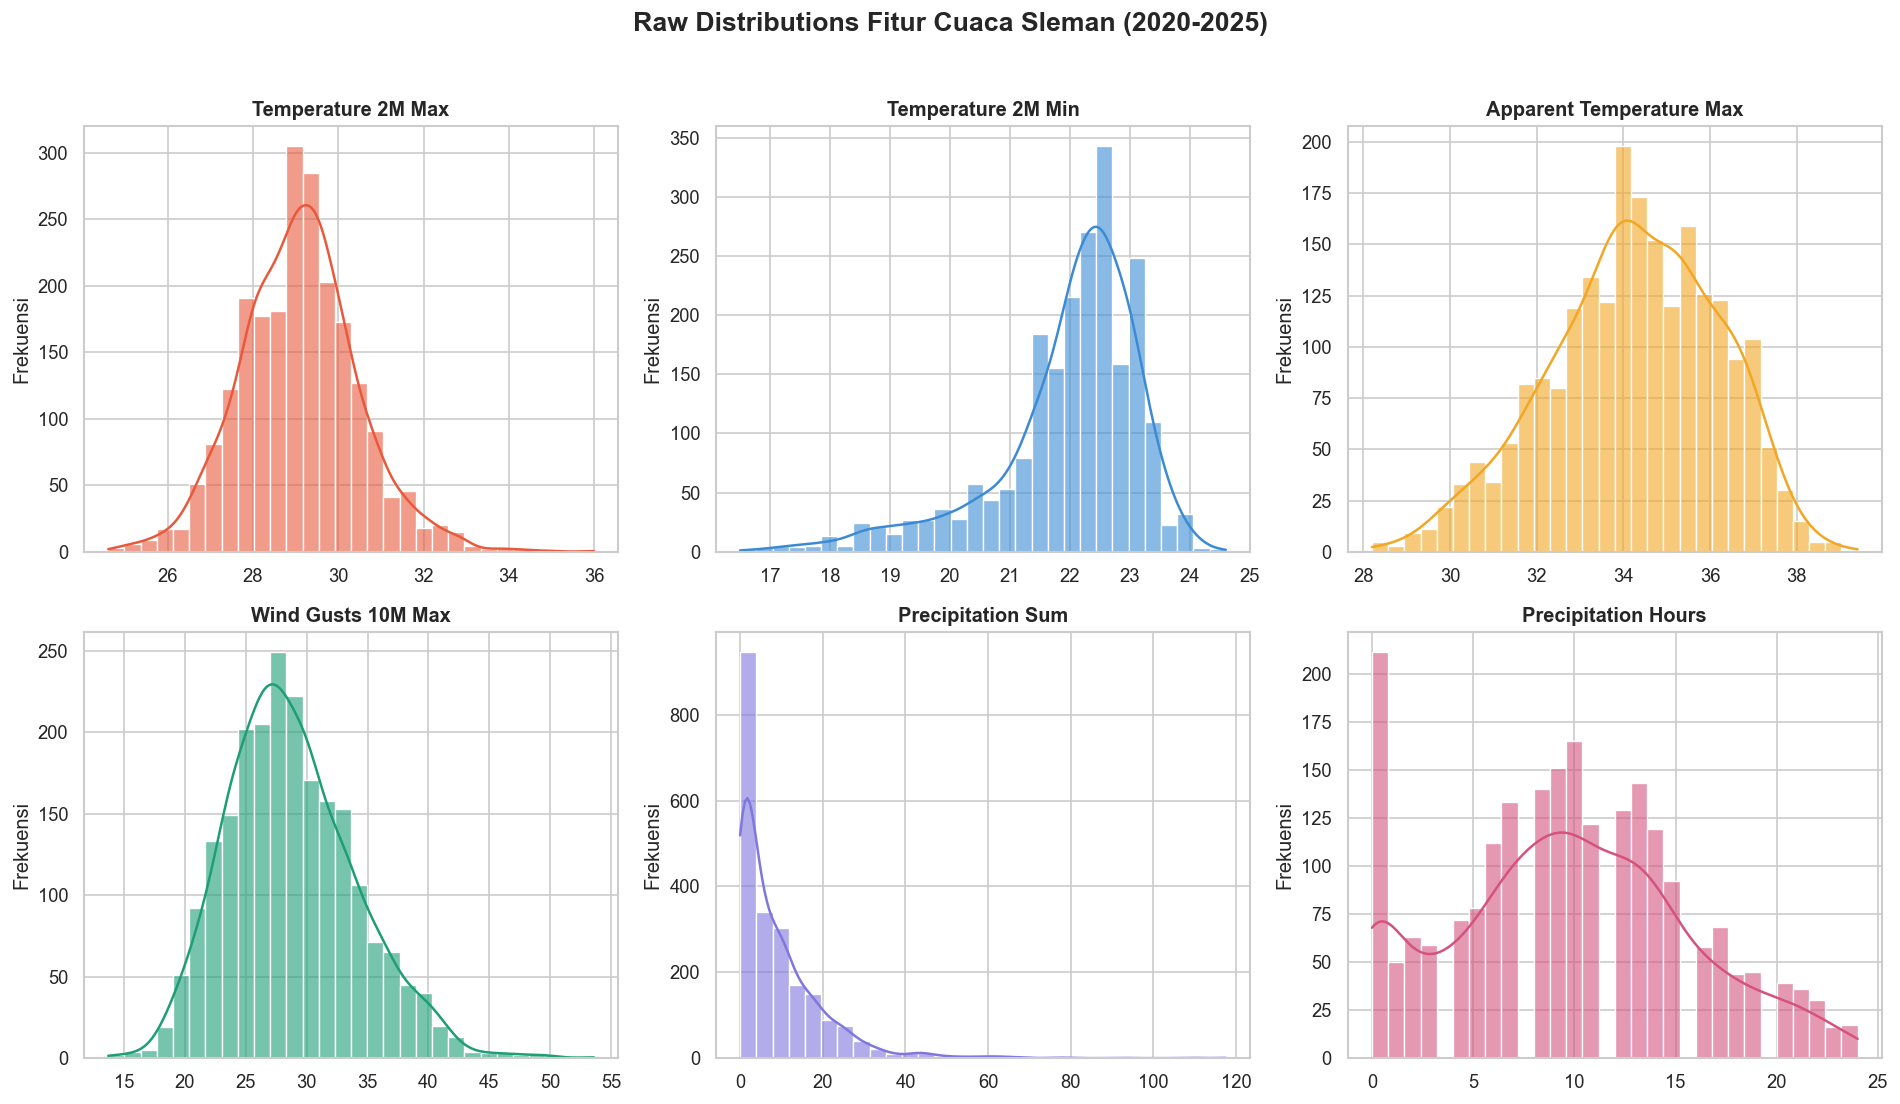

In [7]:
#plot raw data
features = ['temperature_2m_max', 'temperature_2m_min', 'apparent_temperature_max','wind_gusts_10m_max', 'precipitation_sum', 'precipitation_hours']

features_to_plot = [col for col in features if col in df.columns]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 9))
axes = axes.flatten()
colors = ['#E8593C', '#3B8BD4', '#F2A623', '#1D9E75', '#7F77DD', '#D4537E']

for i, col in enumerate(features_to_plot):
    sns.histplot(
        df[col].dropna(), 
        kde=True, 
        ax=axes[i], 
        color=colors[i], 
        bins=30, 
        edgecolor='white',
        alpha=0.6
    )
    
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frekuensi')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Raw Distributions Fitur Cuaca Sleman (2020-2025)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**initial data qualitity**

rangkuman kualitas data dataset cuaca Sleman
1. tidak ada missing values di seluruh kolom sehingga tidak butuh imputasi.
2. mean curah hujan 9.02 dan 75% data berada di bawah 12.90. Tapi, nilai maksimumnya melonjak sangat jauh hingga 117.50. Oleh karena itu secara angka adanya kejadian hujan badai yang ekstrem.
3. 75% dari waktu kecepatan angin di bawah 32.0, tapi tiba-tiba ada nilai maksimum di angka 53.60.

In [8]:
#cek implisit missing value
kalender_ideal = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
missing_dates = kalender_ideal.difference(df.index)

print(f"jumlah hari yang hilang: {len(missing_dates)}")

if len(missing_dates) > 0:
    print("\ntanggal yang hilang:")
    print(missing_dates.tolist())
else:
    print("aman")

jumlah hari yang hilang: 0
aman


In [9]:
dup_count = df.duplicated().sum()
print(f"data yang duplikat: {dup_count}")
print(f"persentase duplikat: {dup_count / len(df) * 100:.2f}%")

data yang duplikat: 0
persentase duplikat: 0.00%


pada dataset ini tidak ada data yang hilang baik ekplisit maupun implisit. selain itu data ini tidak memiliki duplikat yang berarti deduplication tidak diperlukan.

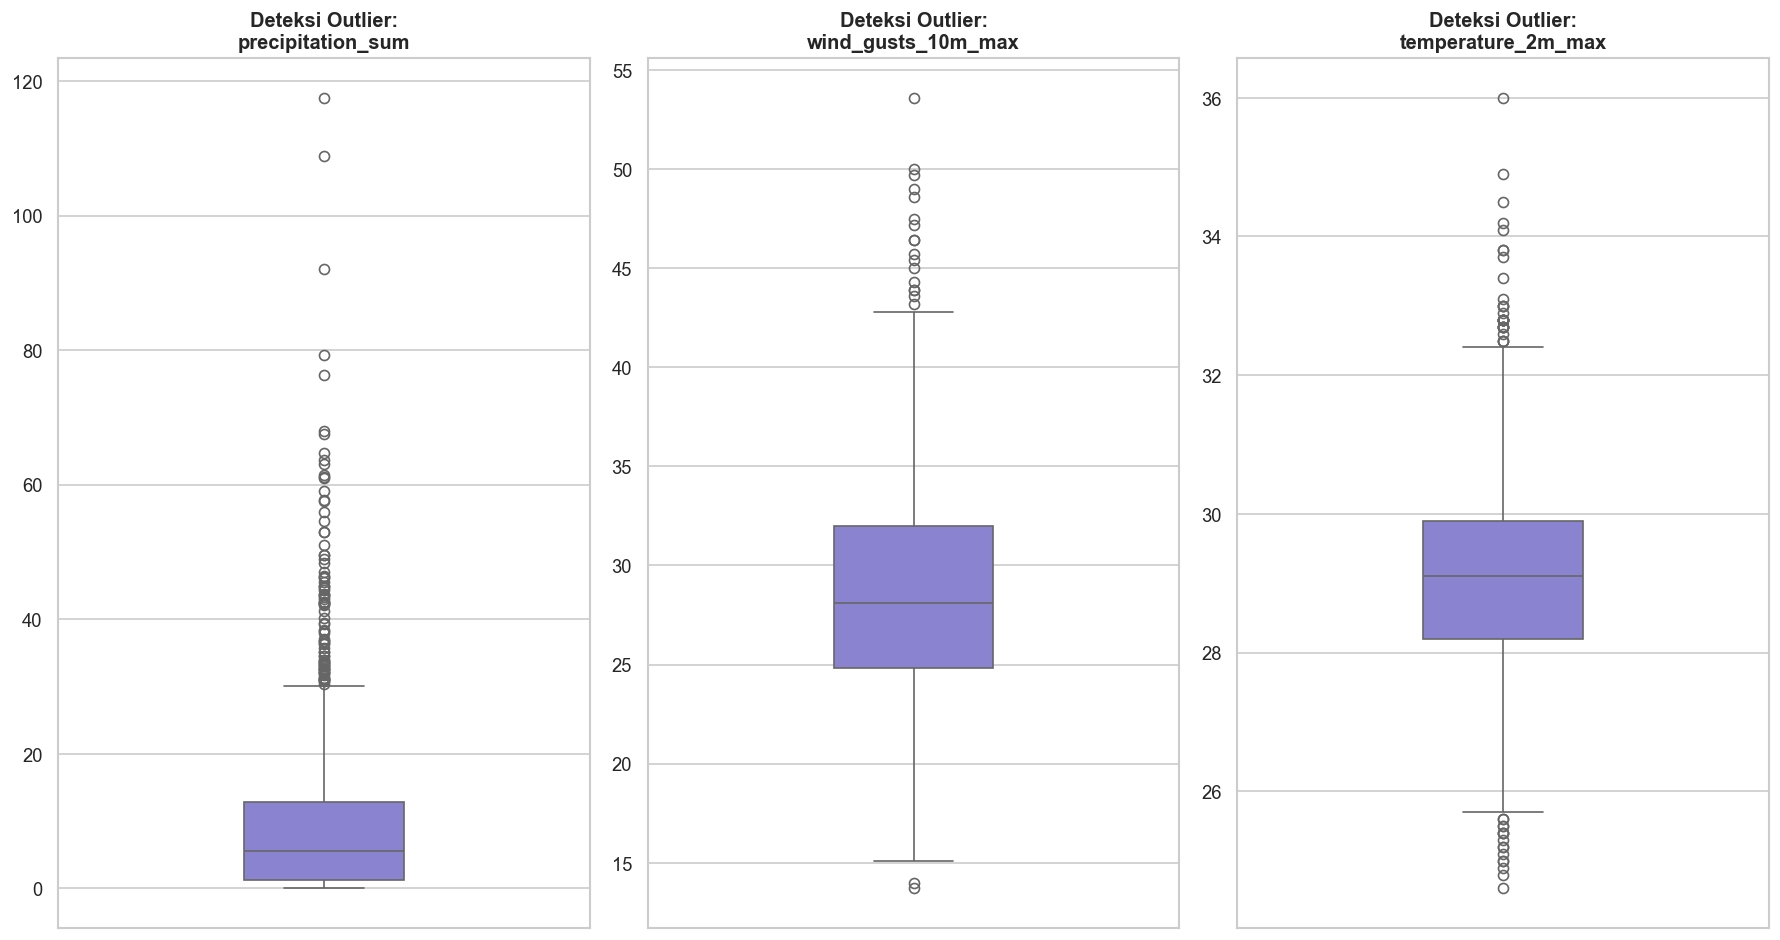

In [10]:
#box plot
plt.figure(figsize=(15, 8))

fitur_outlier = ['precipitation_sum', 'wind_gusts_10m_max', 'temperature_2m_max']

for i, col in enumerate(fitur_outlier, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col].dropna(), color='#7F77DD', width=0.3)
    plt.title(f'Deteksi Outlier:\n{col}', fontweight='bold')
    plt.ylabel('')

plt.tight_layout()
plt.show()

berdasarkan box plot:
1. pada `precipitation_sum` terlihat hujan lebat/badai adalah fenomena yang memiliki frekuensi terjadinya cukup sering.
2. pada `temperature_2m_max`, anomali pada suhu terjadi di 2 arah.
3. `wind_gusts_10m_max` relatif stabil tetapi juga ada kejadian angin ribut/kencang. 

# 03. Feature Engineering

**cuaca extrem**

Cuaca ekstrem dapat digolongkan jika terjadi fluktuasi drastis dari siang hari ke malam sehingga butuh dibutuhkan fungsi yang menghitung selisih suhu max dan min. Namun, karena data yang besar akan dibandingkan rata-rata 30 hari terakhir. Nilai Z-score akan menjawab seberapa menyimpang suhu hari tersebut dengan tren pada bulan tersebut.

**hujan**

hujan 50mm dalam 1 hari wajar tetapi jika 3 hari berturut-turut itu adalah sebuah potensi banjir bandang sehingga model ini akan mengakumulasikan hal tersebut. fitur ini juga akan membandingkan nilainya dengan tren pada bulan tersebut.

**waktu**

secara kalender, bulan january dan descember bersebelahan secara waktu sehingga perlu dibengkokkan garis waktu linear menjadi sebuah lingkaran dan titik descember dan titik january saling terhubung berdampingan.

In [11]:
#termal
df['temp_range'] = df['temperature_2m_max'] - df['temperature_2m_min']
df['temp_max_zscore'] = (
    (df['temperature_2m_max'] - df['temperature_2m_max'].rolling(30, min_periods=7).mean())
    / df['temperature_2m_max'].rolling(30, min_periods=7).std()
)

#hujan dan kumulatif 3 hari untuk mendeteksi potensi banjir
df['precip_3d_cumsum'] = df['precipitation_sum'].rolling(3, min_periods=1).sum()
df['precip_zscore'] = (
    (df['precipitation_sum'] - df['precipitation_sum'].rolling(30, min_periods=7).mean())
    / (df['precipitation_sum'].rolling(30, min_periods=7).std() + 1e-6)
)

#waktu (cyclical encoding agar model paham des dan jan itu berdekatan)
df['month'] = df.index.month
df['year']  = df.index.year
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

#gapus baris awal yang NaN karena efek rolling (7 hari pertama)
df = df.dropna()
print("fitur don")

fitur don


# 04. Modeling

untuk mencegah bias karena rentang yang berbeda, normalisasi dilakukan terlebih dahulu. RobustScaler dapat mempertahankan outlier untuk deteksi karena pakai median dan iqr.

In [38]:
kolom_lama = ['score_hujan', 'score_suhu', 'anomali_hujan', 'anomali_suhu', 'is_extreme']
df = df.drop(columns=[k for k in kolom_lama if k in df.columns])

fitur_hujan_angin = ['precipitation_sum', 'wind_gusts_10m_max', 'precip_3d_cumsum', 'precip_zscore']
fitur_suhu = ['temperature_2m_max', 'temp_range', 'temp_max_zscore']

df_model = df[MODEL_FEATURES].copy()

scaler = RobustScaler()
X_hujan = scaler.fit_transform(df[fitur_hujan_angin])
X_suhu = scaler.fit_transform(df[fitur_suhu])

print(f"dimensi data Hujan: {X_hujan.shape}")
print(f"dimensi data Suhu : {X_suhu.shape}")

dimensi data Hujan: (2186, 4)
dimensi data Suhu : (2186, 3)


In [40]:
iso_hujan = IsolationForest(random_state=RANDOM_STATE)
iso_suhu = IsolationForest(random_state=RANDOM_STATE)

iso_hujan.fit(X_hujan)
iso_suhu.fit(X_suhu)

df['score_hujan'] = iso_hujan.decision_function(X_hujan) # -1 jika hujan badai
df['score_suhu'] = iso_suhu.decision_function(X_suhu) # -1 jika gelombang panas

baseline_hujan = df[df['year'].isin([2020, 2021])]['score_hujan']
baseline_suhu = df[df['year'].isin([2020, 2021])]['score_suhu']

batas_hujan = np.percentile(baseline_hujan, 2)
batas_suhu = np.percentile(baseline_suhu, 2)

df['anomali_hujan'] = (df['score_hujan'] <= batas_hujan).astype(int)
df['anomali_suhu'] = (df['score_suhu'] <= batas_suhu).astype(int)

df['is_extreme'] = ((df['anomali_hujan'] == 1) | (df['anomali_suhu'] == 1)).astype(int)
print(f"batas skor hujan (baseline 2020-2021) : {batas_hujan:.4f}")
print(f"batas skor suhu  (baseline 2020-2021) : {batas_suhu:.4f}\n")

n_ekstrem = df['is_extreme'].sum()
print(f"ditemukan {n_ekstrem} hari cuaca ekstrem secara total.")
print(f"- ekstrem karena hujan/angin : {df['anomali_hujan'].sum()} hari")
print(f"- ekstrem karena suhu panas  : {df['anomali_suhu'].sum()} hari")

tren_natural = df.groupby('year')['is_extreme'].mean() * 100
print("\npersentase hari ekstrem per tahun (tren natural):")
print(tren_natural.round(2).astype(str) + ' %')

batas skor hujan (baseline 2020-2021) : -0.1552
batas skor suhu  (baseline 2020-2021) : -0.1156

ditemukan 73 hari cuaca ekstrem secara total.
- ekstrem karena hujan/angin : 24 hari
- ekstrem karena suhu panas  : 51 hari

persentase hari ekstrem per tahun (tren natural):
year
2020    3.61 %
2021    4.38 %
2022    3.56 %
2023    3.84 %
2024    1.91 %
2025    2.74 %
Name: is_extreme, dtype: str


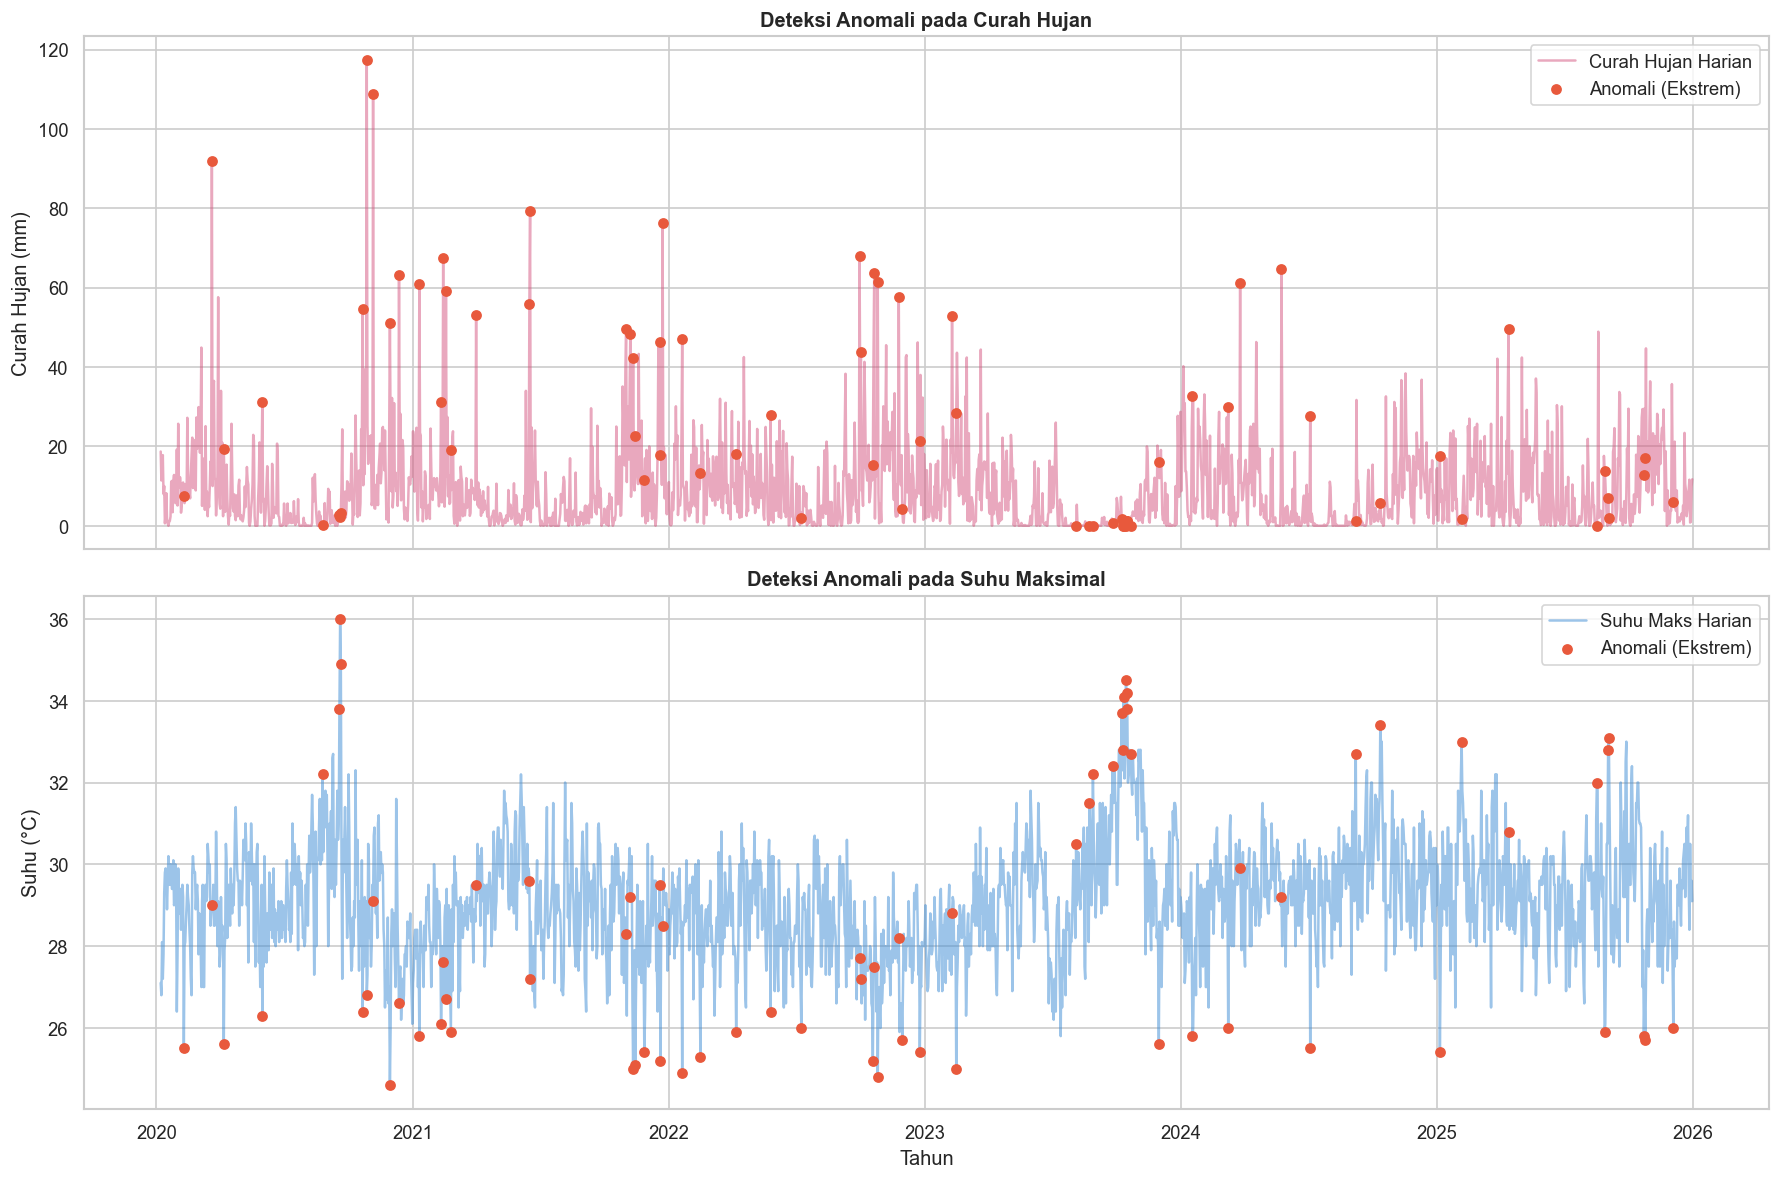

In [42]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

#pisah data extrem untuk plotting
hari_normal = df[df['is_extreme'] == 0]
hari_ekstrem = df[df['is_extreme'] == 1]

#curah hujan
ax1.plot(df.index, df['precipitation_sum'], color='#D4537E', alpha=0.5, label='Curah Hujan Harian')
ax1.scatter(hari_ekstrem.index, hari_ekstrem['precipitation_sum'], color='#E8593C', s=30, label='Anomali (Ekstrem)', zorder=5)
ax1.set_title('Deteksi Anomali pada Curah Hujan', fontweight='bold')
ax1.set_ylabel('Curah Hujan (mm)')
ax1.legend()

#temperal
ax2.plot(df.index, df['temperature_2m_max'], color='#3B8BD4', alpha=0.5, label='Suhu Maks Harian')
ax2.scatter(hari_ekstrem.index, hari_ekstrem['temperature_2m_max'], 
            color='#E8593C', s=30, label='Anomali (Ekstrem)', zorder=5)
ax2.set_title('Deteksi Anomali pada Suhu Maksimal', fontweight='bold')
ax2.set_ylabel('Suhu (°C)')
ax2.set_xlabel('Tahun')
ax2.legend()

plt.tight_layout()
plt.show()

# 05. Interpretation & Model Evaluation

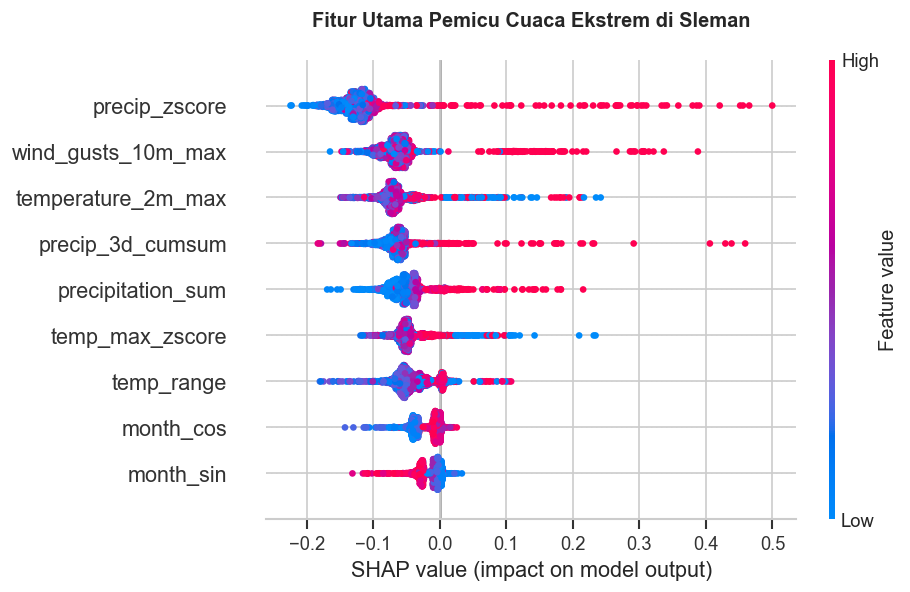

In [ ]:
MODEL_FEATURES = fitur_hujan_angin + fitur_suhu
X_scaled = scaler.fit_transform(df[MODEL_FEATURES])

rfc = RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced')
rfc.fit(X_scaled, df['is_extreme'])

explainer = shap.TreeExplainer(rfc)
shap_values = explainer.shap_values(X_scaled)

if isinstance(shap_values, list):
    #kalo list, ambil elemen index 1
    sv_plot = shap_values[1]
elif len(shap_values.shape) == 3:
    #kalo array 3D, ambil semua baris, semua fitur, khusus kelas index 1
    sv_plot = shap_values[:, :, 1]
else:
    #kalo udah 2d dari awal
    sv_plot = shap_values

plt.title("Fitur Utama Pemicu Cuaca Ekstrem di Sleman", fontweight='bold', pad=20)
shap.summary_plot(sv_plot, X_scaled, feature_names=MODEL_FEATURES)

fitur-fitur turunan lebih dominan daripada fitur mentah. dari data ini, 
1. jika `precip_zscore` dan `wind_gusts` semakin tinggi, itulah pertanda kuat cuaca extrem
2. jika siang hari tiba-tiba menjadi dingin, akan dicurigakan bahwa cuaca extreem
3. cuaca extrem tidak terpengaruhi oleh bulan jadi murni dipicu oleh kondisi angin dan awan.

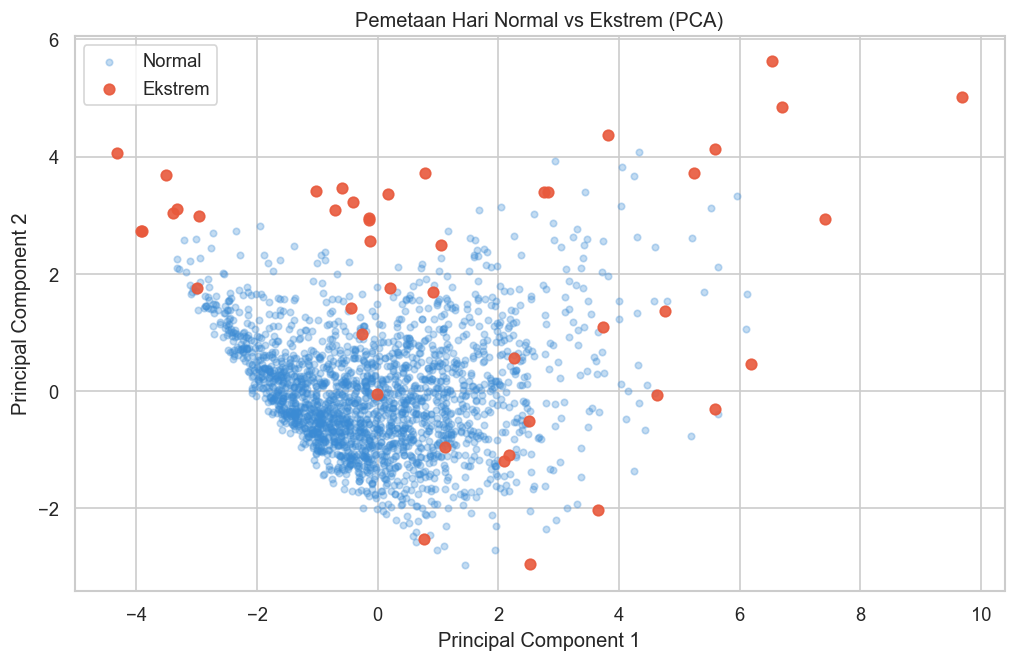

In [31]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[df['is_extreme']==0, 0], X_pca[df['is_extreme']==0, 1], 
            c='#3B8BD4', label='Normal', alpha=0.3, s=15)
plt.scatter(X_pca[df['is_extreme']==1, 0], X_pca[df['is_extreme']==1, 1], 
            c='#E8593C', label='Ekstrem', alpha=0.9, s=40)

plt.title('Pemetaan Hari Normal vs Ekstrem (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

berdasarkan grafik PCA terdapat beberapa notes penting:
1. data extrem jauh lebih sedikit dari normal, secara di dunia nyata ini normal tetapi harus dipertimbangkan saat training sehingga model tidak malas menebak dan terus mengatakan normal.
2. titik merah menyebar jauh sehingga model secara mudah dan akurat mendeteksi hari-hari tersebut.
3. masih banyak area overlap yang sulit diprediksi dan berpotensi model salah nebak. 

# 06. Tren Analisis

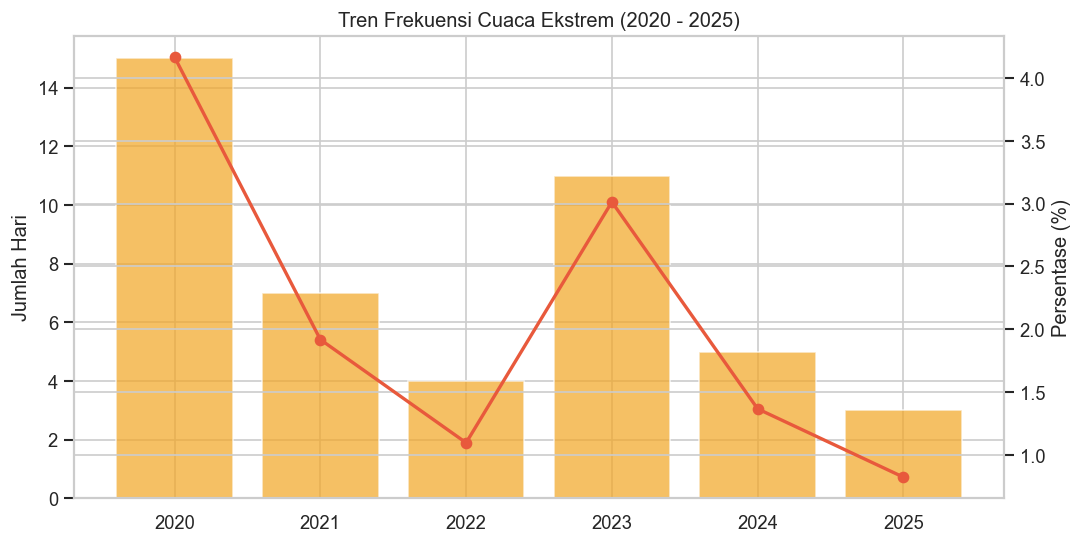

In [33]:
yearly = df.groupby('year')['is_extreme'].agg(['sum', 'count'])
yearly['pct_ekstrem'] = (yearly['sum'] / yearly['count'] * 100)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.bar(yearly.index, yearly['sum'], color='#F2A623', alpha=0.7, label='Jumlah Hari Ekstrem')
ax2.plot(yearly.index, yearly['pct_ekstrem'], 'o-', color='#E8593C', linewidth=2, label='% dari Total Hari')

ax1.set_ylabel('Jumlah Hari')
ax2.set_ylabel('Persentase (%)')
ax1.set_title('Tren Frekuensi Cuaca Ekstrem (2020 - 2025)')
plt.show()